# Code for Chapter 9 @ SSTC-NEU modified by Fu
## Word Embeddings

In [2]:
import torch # torch will allow us to create tensors.
import torch.nn as nn # torch.nn allows us to create a neural network and allows
                      # us to access a lot of useful functions like:
                      # nn.Linear, nn.Embedding, nn.CrossEntropyLoss() etc.

from torch.optim import Adam # optim contains many optimizers. This time we're using Adam
from torch.distributions.uniform import Uniform # So we can initialize our tensors with a uniform distribution
from torch.utils.data import TensorDataset, DataLoader # these are needed for the training data

import lightning as L # lightning has tons of cool tools that make neural networks easier

import pandas as pd ## to create dataframes from graph input
import matplotlib.pyplot as plt ## matplotlib allows us to draw graphs.
import seaborn as sns ## seaborn makes it easier to draw nice-looking graphs.

## NOTE: If you get an error running this block of code, it is probably
##       because you installed a new package earlier and forgot to
##       restart your session for python to find the new module(s).
##
##       To restart your session:
##       - In Google Colab, click on the "Runtime" menu and select
##         "Restart Session" from the pulldown menu
##       - In a local jupyter notebook, click on the "Kernel" menu and select
##         "Restart Kernel" from the pulldown menu

In [3]:
## create the training data for the neural network.
inputs = torch.tensor([[1., 0., 0., 0.], # one-hot-encoding for Troll 2...
                       [0., 1., 0., 0.], # ...is
                       [0., 0., 1., 0.], # ...great
                       [0., 0., 0., 1.]]) # ...Gymkata

labels = torch.tensor([[0., 1., 0., 0.], # "Troll 2" is followed by "is"
                       [0., 0., 1., 0.], # "is" is followed by "great"
                       [0., 0., 0., 1.], # "great" isn't followed by anything, but we'll pretend it was followed by "Gymkata"
                       [0., 1., 0., 0.]]) # "Gymkata", just like "Troll 2", is followed by "is".

In [4]:
dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset)

In [5]:
class WordEmbeddingFromScratch(L.LightningModule):

    def __init__(self):
        ## __init__() initializes the weights and sets everything up for training

        super().__init__()

        ## The first thing we do is set the seed for the random number generorator.
        ## This ensures that when someone creates a model from this class, that model
        ## will start off with the exact same random numbers as I started out with when
        ## I created this demo. At least, I hope that is what happens!!! :)
        L.seed_everything(seed=42)

        ###################
        ##
        ## Initialize the weights.
        ##
        ## NOTE: We're initializing the weights using values from a uniform distribtion
        ##       that goes from -0.5 to 0.5 (this is notated as U(-0.5, 0.5).
        ##       This is because of how nn.Linear() initializes weights -
        ##       nn.Linear() uses U(-sqrt(k), sqrt(k)), where k=1/in_features.
        ##       In our case, we have 4 inputs, so k=1/4 = 0.25. And the sqrt(0.25) = 0.5.
        ##       Thus, nn.Linear() would use U(-0.5, 0.5) to initialize the weights, so
        ##       that's what we'll do here as well.
        ##
        ###################
        min_value = -0.5
        max_value = 0.5

        ## Now we initialize the weights that feed 4 inputs (one for each unique word)
        ##       into the 2 nodes in the hidden layer (top and bottom nodes)
        ##
        ## NOTE: Because we want words (or tokens) that are used in the same context to have similar
        ##       weights, we are excluding bias terms from the connections from the inputs to the
        ##       nodes in the hidden layer (alternatively, you could think that
        ##       we set the bias terms to 0 and are not going to optimize them).
        ##
        ## ALSO NOTE: We're using nn.Parameter() here instead of torch.tensor() because we want
        ##       to easily print out the parameters before and after training. Parameters are just
        ##       tensors that are added to model's parameter list.
        self.input1_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input1_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.input2_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input2_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.input3_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input3_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.input4_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input4_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        ## Now we initialize the weights that come out of the hidden layer to the "output"
        ## NOTE: Again, we are excluding bias terms. This time, we exclude them simply because
        ##       we do not need them.
        self.output1_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output1_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.output2_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output2_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.output3_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output3_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.output4_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output4_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        ## For the loss function, we'll use CrossEntropyLoss, which we'll use in training_step()
        ## NOTE: The nn.CrossEntropyLoss automatically applies softmax for us, so we don't need to import it.
        self.loss = nn.CrossEntropyLoss()


    def forward(self, input):
        ## forward() is where we do the math associated with running the inputs through the
        ## network

        ## The input is delivered inside of a list, like this...
        ##   [[1., 0., 0., 0.]]
        ## ...and it's just easier if we remove the extra pair of brackets so we only have...
        ##   [1., 0., 0., 0.]
        ## ...so let's do it.
        input = input[0]

        ## First, for the top node in the hidden layer,
        ## we multiply each input by its weight,
        ## and then calculate the sum of those products...
        inputs_to_top_hidden = ((input[0] * self.input1_w1) +
                                (input[1] * self.input2_w1) +
                                (input[2] * self.input3_w1) +
                                (input[3] * self.input4_w1))

        ## ...then, for the bottom node in the hidden layer,
        ## we multiply each input by its weight,
        ## and then calculate the sum of those products.
        inputs_to_bottom_hidden = ((input[0] * self.input1_w2) +
                                   (input[1] * self.input2_w2) +
                                   (input[2] * self.input3_w2) +
                                   (input[3] * self.input4_w2))

        ## Now, in theory, we could run inputs_to_top_hidden and inputs_to_bottom_hidden through
        ## linear activation functions, but the outputs would be the exact same as in the inputs,
        ## so we can just skip that step and instead compute the 4 output values from the 2 nodes in hidden layer
        ## by summing the products of the hidden layer values and a pair of weights for each output.
        output1 = ((inputs_to_top_hidden * self.output1_w1) +
                   (inputs_to_bottom_hidden * self.output1_w2))
        output2 = ((inputs_to_top_hidden * self.output2_w1) +
                   (inputs_to_bottom_hidden * self.output2_w2))
        output3 = ((inputs_to_top_hidden * self.output3_w1) +
                   (inputs_to_bottom_hidden * self.output3_w2))
        output4 = ((inputs_to_top_hidden * self.output4_w1) +
                   (inputs_to_bottom_hidden * self.output4_w2))

        ## Now we need to concatenate the 4 output tensors so that we can run them through
        ## the SoftMax function. However, because they are tensors (and have gradients attached to them),
        ## we can't just combine them in a simple list like this...
        # output_values = [output1, output2, output3, output4] ## THIS WILL NOT WORK
        ## ...because that would strip off the gradients.
        ## Instead, we use torch.stack(), which retains the gradients.
        output_presoftmax = torch.stack([output1, output2, output3, output4])
        ## NOTE: The the loss function we are using, nn.CrossEntropyLoss, automatically applies softmax for us, so we
        ##       need to do that ourselves. If we want to actually use this network to predict the next word
        ##       (instead of just using it for the Word Embedding values), then we'll need to apply the softmax() function
        ##       ourselves (or just look to see what output value is largest).

        return(output_presoftmax)


    def configure_optimizers(self):
        # configure_optimizers() configures the optimizer we want to use for backpropagation.

        return Adam(self.parameters(), lr=0.1) # lr=0.1 sets the learning rate to 0.1


    def training_step(self, batch):
        # training_step() takes a step of gradient descent.

        input_i, label_i = batch # collect input
        output_i = self.forward(input_i) # run input through the neural network
        loss = self.loss(output_i, label_i[0]) ## loss = cross entropy

        return loss

In [6]:
modelFromScratch = WordEmbeddingFromScratch() # create the model...

print("Before optimization, the parameters are...")
for name, param in modelFromScratch.named_parameters():
    print(name, torch.round(param.data, decimals=2))

Before optimization, the parameters are...
input1_w1 tensor(0.3800)
input1_w2 tensor(0.4200)
input2_w1 tensor(-0.1200)
input2_w2 tensor(0.4600)
input3_w1 tensor(-0.1100)
input3_w2 tensor(0.1000)
input4_w1 tensor(-0.2400)
input4_w2 tensor(0.2900)
output1_w1 tensor(0.4400)
output1_w2 tensor(-0.3700)
output2_w1 tensor(0.4300)
output2_w2 tensor(0.0900)
output3_w1 tensor(0.3700)
output3_w2 tensor(0.0700)
output4_w1 tensor(0.2400)
output4_w2 tensor(-0.0700)


In [7]:
data = {
    "w1": [modelFromScratch.input1_w1.item(), ## item() pulls out the tensor value as a float
           modelFromScratch.input2_w1.item(),
           modelFromScratch.input3_w1.item(),
           modelFromScratch.input4_w1.item()],
    "w2": [modelFromScratch.input1_w2.item(),
           modelFromScratch.input2_w2.item(),
           modelFromScratch.input3_w2.item(),
           modelFromScratch.input4_w2.item()],
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,0.382269,0.415004,Troll2,input1
1,-0.117136,0.459306,is,input2
2,-0.109552,0.100895,great,input3
3,-0.243428,0.293641,Gymkata,input4


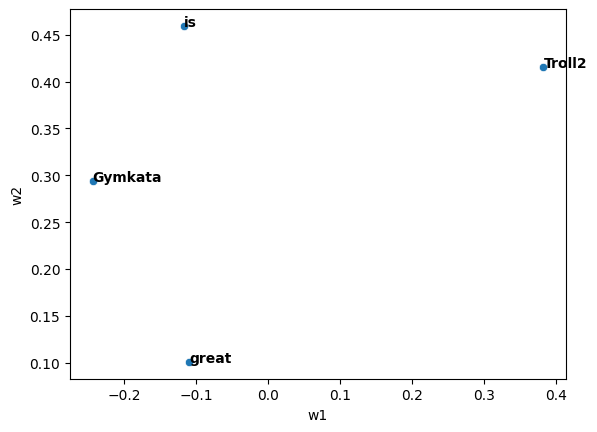

In [8]:
sns.scatterplot(data=df, x="w1", y="w2")

## add the token that each dot represents to the graph
# Troll 2
plt.text(df.w1[0], df.w2[0], df.token[0],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# is
plt.text(df.w1[1], df.w2[1], df.token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# great
plt.text(df.w1[2], df.w2[2], df.token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# Gymkata
plt.text(df.w1[3], df.w2[3], df.token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

In [9]:
trainer = L.Trainer(max_epochs=100)
trainer.fit(modelFromScratch, train_dataloaders=dataloader)

2026-04-13 16:00:44.888967: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-13 16:00:44.945675: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-13 16:00:44.948262: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda-12.3/lib64
2026-04-13 16:00:44.948271: I tensorflow/stream_executor/cuda/cudart_stub.cc:29]

Training: |          | 0/? [00:00<?, ?it/s]

In [10]:
print("After optimization, the parameters are...")
for name, param in modelFromScratch.named_parameters():
    print(name, torch.round(param.data, decimals=2))

After optimization, the parameters are...
input1_w1 tensor(2.0200)
input1_w2 tensor(1.9400)
input2_w1 tensor(-2.1800)
input2_w2 tensor(2.3200)
input3_w1 tensor(-2.0300)
input3_w2 tensor(-2.1600)
input4_w1 tensor(1.6900)
input4_w2 tensor(1.8900)
output1_w1 tensor(1.2600)
output1_w2 tensor(-1.7700)
output2_w1 tensor(3.0800)
output2_w2 tensor(1.3600)
output3_w1 tensor(-1.5800)
output3_w2 tensor(0.8800)
output4_w1 tensor(-1.5700)
output4_w2 tensor(-3.2900)


In [11]:
data = {
    "w1": [modelFromScratch.input1_w1.item(), ## item() pulls out the tensor value as a float
           modelFromScratch.input2_w1.item(),
           modelFromScratch.input3_w1.item(),
           modelFromScratch.input4_w1.item()],
    "w2": [modelFromScratch.input1_w2.item(),
           modelFromScratch.input2_w2.item(),
           modelFromScratch.input3_w2.item(),
           modelFromScratch.input4_w2.item()],
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,2.015857,1.941367,Troll2,input1
1,-2.181994,2.318634,is,input2
2,-2.028361,-2.161812,great,input3
3,1.691290,1.894234,Gymkata,input4


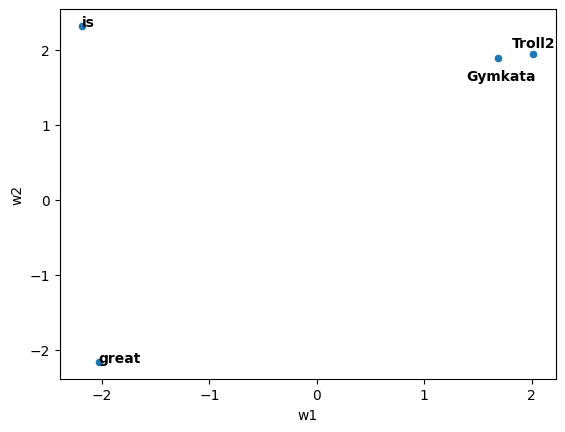

In [12]:
sns.scatterplot(data=df, x="w1", y="w2")

## NOTE: For Troll2 and and Gymkata, we're adding offsets to where to print the tokens because otherwise
## they will be so close to each other that they will overlap and be unreadable.

## Troll 2
plt.text(df.w1[0]-0.2, df.w2[0]+0.1, df.token[0],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

## is
plt.text(df.w1[1], df.w2[1], df.token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

## great
plt.text(df.w1[2], df.w2[2], df.token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

## gymkata
plt.text(df.w1[3]-0.3, df.w2[3]-0.3, df.token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

In [13]:
## Let's see what the model predicts

## First, let's create a softmax object...
softmax = nn.Softmax(dim=0) ## dim=0 applies softmax to rows, dim=1 applies softmax to columns

# Note that the forward() method is flattening the input, i.e., input = input[0].
# Because we are stacking 4 scalar values, the shape of the output vector 
# is a 1D tensor with shape (4), i.e., [val1, val2, val3, val4]:
# output_presoftmax = torch.stack([output1, output2, output3, output4])
# Therefore dim=0 applies softmax to the only dimension (the list of values)

## Now let's...

## print the predictions for "Troll2"
print(torch.round(softmax(modelFromScratch(torch.tensor([[1., 0., 0., 0.]]))),
                  decimals=2))

## print the predictions for "is"
print(torch.round(softmax(modelFromScratch(torch.tensor([[0., 1., 0., 0.]]))),
                  decimals=2))

## print the predictions for "great"
print(torch.round(softmax(modelFromScratch(torch.tensor([[0., 0., 1., 0.]]))),
                  decimals=2))

## print the predictions for "Gymkata"
print(torch.round(softmax(modelFromScratch(torch.tensor([[0., 0., 0., 1.]]))),
                  decimals=2))

tensor([0., 1., 0., 0.], grad_fn=<RoundBackward1>)
tensor([0., 0., 1., 0.], grad_fn=<RoundBackward1>)
tensor([0., 0., 0., 1.], grad_fn=<RoundBackward1>)
tensor([0., 1., 0., 0.], grad_fn=<RoundBackward1>)


In [14]:
class WordEmbeddingWithLinear(L.LightningModule):

    def __init__(self):

        super().__init__()

        ## The first thing we do is set the seed for the random number generorator.
        ## This ensures that when someone creates a model from this class, that model
        ## will start off with the exact same random numbers as I started out with when
        ## I created this demo. At least, I hope that is what happens!!! :)
        L.seed_everything(seed=42)

        ## In order to initialize weights from the 4 inputs (one for each unique word)
        ##       to the 2 nodes in the hidden layer (top and bottom nodes), we simply make
        ##       one call to nn.Linear() where in_features specifies the number of
        ##       inputs and out_features specifies the number of nodes we
        ##       are connecting them to. Since we don't want to use bias terms,
        ##       we set bias=False
        self.input_to_hidden = nn.Linear(in_features=4, out_features=2, bias=False)
        ## Now, in order to connect the 2 nodes in the hidden layer to the 4 outputs, we
        ##       make one call to nn.Linear(), where in_features specifies the number of
        ##       nodes in hidden layer and out_features specifies the number of output values we want.
        ##       And again, we can set bias=False
        self.hidden_to_output = nn.Linear(in_features=2, out_features=4, bias=False)

        ## We'll use CrossEntropyLoss in training_step()
        self.loss = nn.CrossEntropyLoss()


    def forward(self, input):

        ## Unlike before, where we did all the math by hand, now we can
        ## simply pass the input values to the weights we created with nn.Linear()
        ## between the input and the hidden layer and save the result in "hidden"
        ##
        ## NOTE: Unlike before, we don't need to strip off the extra brackets from the
        ##       input. the Linear ojbect knows what to do.
        hidden = self.input_to_hidden(input)

        ## Then we pass "hidden" to the weights we created with nn.Linear()
        ## between the hidden layer and the output.
        output_values = self.hidden_to_output(hidden)

        return(output_values)


    def configure_optimizers(self):
        # this configures the optimizer we want to use for backpropagation.

        return Adam(self.parameters(), lr=0.1)


    def training_step(self, batch):
        # take a step during gradient descent.

        input_i, label_i = batch # collect input
        output_i = self.forward(input_i) # run input through the neural network
        loss = self.loss(output_i, label_i) ## loss = cross entropy

        return loss

In [15]:
modelLinear = WordEmbeddingWithLinear()

print("Before optimization, the parameters are...")
for name, param in modelLinear.named_parameters():
    print(name, torch.round(param.data, decimals=2))

Before optimization, the parameters are...
input_to_hidden.weight tensor([[ 0.3800,  0.4200, -0.1200,  0.4600],
        [-0.1100,  0.1000, -0.2400,  0.2900]])
hidden_to_output.weight tensor([[ 0.6200, -0.5200],
        [ 0.6100,  0.1300],
        [ 0.5200,  0.1000],
        [ 0.3400, -0.1000]])


In [16]:
data = {
    ## NOTE: Unlike before, when we called item() on each individual
    ##       Weight, now that we are using nn.Linear, we access the
    ##       Weights with ".weight". We then have to remove the gradients
    ##       associated with each Weight, so we also call .detach().
    ##       Lastly, we then convert the tensor to a numpy array with
    ##       numpy().
    "w1": modelLinear.input_to_hidden.weight.detach()[0].numpy(), # [0] = Weights to top activation function
    "w2": modelLinear.input_to_hidden.weight.detach()[1].numpy(), # [1] = Weights to bottom activation function
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,0.382269,-0.109552,Troll2,input1
1,0.415004,0.100895,is,input2
2,-0.117136,-0.243428,great,input3
3,0.459306,0.293641,Gymkata,input4


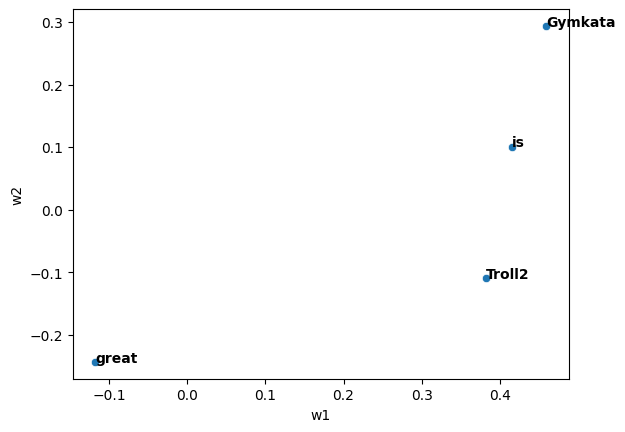

In [17]:
sns.scatterplot(data=df, x="w1", y="w2")

## add the token each dot represents to the graph

## Troll 2
plt.text(df.w1[0], df.w2[0], df.token[0],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
## is
plt.text(df.w1[1], df.w2[1], df.token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
## great
plt.text(df.w1[2], df.w2[2], df.token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

## Gymkata
plt.text(df.w1[3], df.w2[3], df.token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

In [18]:
trainer = L.Trainer(max_epochs=100)
trainer.fit(modelLinear, train_dataloaders=dataloader)

/home/chason/anaconda3/envs/jupyter-server/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/chason/anaconda3/envs/jupyter-server/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/home/chason/anaconda3/envs/jupyter-server/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

In [19]:
print("After optimization, the parameters are...")
for name, param in modelLinear.named_parameters():
    print(name, param.data)

After optimization, the parameters are...
input_to_hidden.weight tensor([[ 2.5104, -1.0176, -1.9742,  2.4355],
        [-0.0688,  2.4824, -1.8189, -0.2228]])
hidden_to_output.weight tensor([[-0.3022, -1.0102],
        [ 3.2008, -0.3850],
        [-0.6693,  2.1813],
        [-2.6841, -2.9578]])


In [20]:
data = {
    "w1": modelLinear.input_to_hidden.weight.detach()[0].numpy(),
    "w2": modelLinear.input_to_hidden.weight.detach()[1].numpy(),
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,2.510441,-0.068819,Troll2,input1
1,-1.017648,2.482439,is,input2
2,-1.974156,-1.818942,great,input3
3,2.435518,-0.222802,Gymkata,input4


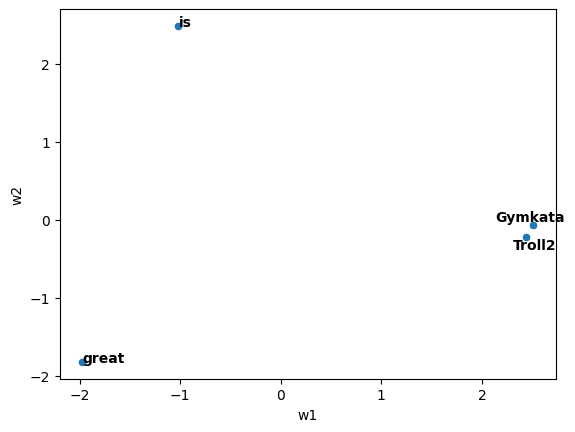

In [21]:
sns.scatterplot(data=df, x="w1", y="w2")

## add the token each dot represents to the graph
## NOTE: For Troll2 and and Gymkata, we're adding offsets to where to print the tokens because otherwise
## they will be so close to each other that they will overlap and be unreadable.

# Troll 2
plt.text(df.w1[0]-0.2, df.w2[0]-0.3, df.token[0],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# is
plt.text(df.w1[1], df.w2[1], df.token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# great
plt.text(df.w1[2], df.w2[2], df.token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# Gymkata
plt.text(df.w1[3]-0.3, df.w2[3]+0.2, df.token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

In [22]:
## Let's see what the model predicts
softmax = nn.Softmax(dim=1) ## dim=0 applies softmax to rows, dim=1 applies softmax to columns

# Unlike the modelFromScratch model, nn.Linear produces a 2D tensor with shape (1, 4),
# preserving the batch dimension: [[val1, val2, val3, val4]].
# Since the classes are arranged across the columns (Dimension 1), we use dim=1 
# to squash the values across the row so they sum to 1.

print(torch.round(softmax(modelLinear(torch.tensor([[1., 0., 0., 0.]]))), decimals=2)) ## print the predictions for "Troll2"
print(torch.round(softmax(modelLinear(torch.tensor([[0., 1., 0., 0.]]))), decimals=2)) ## print the predictions for "is"
print(torch.round(softmax(modelLinear(torch.tensor([[0., 0., 1., 0.]]))), decimals=2)) ## print the predictions for "great"
print(torch.round(softmax(modelLinear(torch.tensor([[0., 0., 0., 1.]]))), decimals=2)) ## print the predictions for "Gymkata"

tensor([[0., 1., 0., 0.]], grad_fn=<RoundBackward1>)
tensor([[0., 0., 1., 0.]], grad_fn=<RoundBackward1>)
tensor([[0., 0., 0., 1.]], grad_fn=<RoundBackward1>)
tensor([[0., 1., 0., 0.]], grad_fn=<RoundBackward1>)


In [23]:
modelLinear.input_to_hidden.weight

Parameter containing:
tensor([[ 2.5104, -1.0176, -1.9742,  2.4355],
        [-0.0688,  2.4824, -1.8189, -0.2228]], requires_grad=True)

In [24]:
##  NOTE: We have to transpose the original embedding values (from w1 and w2) for nn.Embedding()
##        and we do this with adding a '.T' to modelLinear.input_to_hidden.weight.T
word_embeddings = nn.Embedding.from_pretrained(modelLinear.input_to_hidden.weight.T)

In [25]:
word_embeddings.weight

Parameter containing:
tensor([[ 2.5104, -0.0688],
        [-1.0176,  2.4824],
        [-1.9742, -1.8189],
        [ 2.4355, -0.2228]])

In [26]:
word_embeddings(torch.tensor(0)) # retrieve the embedding values for Troll 2...

tensor([ 2.5104, -0.0688])

In [27]:
vocab = {'Troll2': 0,
         'is': 1,
         'great': 2,
         'Gymkata': 3}

In [28]:
word_embeddings(torch.tensor(vocab['Troll2']))

tensor([ 2.5104, -0.0688])

In [29]:
word_embeddings(torch.tensor(vocab['Gymkata']))

tensor([ 2.4355, -0.2228])

In [30]:
class WordEmbeddingWithEmbedding(L.LightningModule):

    def __init__(self):

        super().__init__()

        ## The first thing we do is set the seed for the random number generorator.
        ## This ensures that when someone creates a model from this class, that model
        ## will start off with the exact same random numbers as I started out with when
        ## I created this demo. At least, I hope that is what happens!!! :)
        L.seed_everything(seed=42)

        self.embed = nn.Embedding(4, 2) # 4 = number of words in the vocabulary, 2 = 2 numbers per embedding
        self.hidden_to_output = nn.Linear(2, 4, bias=False)

        ## We'll use CrossEntropyLoss in training_step()
        self.loss = nn.CrossEntropyLoss()


    def forward(self, input):

        hidden = self.embed(input[0])
        output_values = self.hidden_to_output(hidden)

        return(output_values)


    def configure_optimizers(self): # this configures the optimizer we want to use for backpropagation.
        return Adam(self.parameters(), lr=0.1)


    def training_step(self, batch): # take a step during gradient descent.
        input_i, label_i = batch # collect input
        output_i = self.forward(input_i[0]) # run input through the neural network
        loss = self.loss(output_i, label_i[0]) ## self.loss = cross entropy

        return loss

In [31]:
## Create the training data for the neural network.

## NOTE: nn.Embedding() applies one-hot-encoding to the input for us, so
## the data that we use for training will look different from before.
inputsForEmbed = torch.tensor([[0], [1], [2], [3]]) ## NOTE: Troll2 = 0, is = 1, great = 2, Gymkata = 3
labels = torch.tensor([[0., 1., 0., 0.], [0., 0., 1., 0.], [0., 0., 0., 1.], [0., 1., 0., 0.]])

datasetForEmbed = TensorDataset(inputsForEmbed, labels)
dataloaderForEmbed = DataLoader(datasetForEmbed)

In [32]:
modelEmbed = WordEmbeddingWithEmbedding()

print("Before optimization, the parameters are...")
for name, param in modelEmbed.named_parameters():
    print(name, param.data)

Before optimization, the parameters are...
embed.weight tensor([[ 0.3367,  0.1288],
        [ 0.2345,  0.2303],
        [-1.1229, -0.1863],
        [ 2.2082, -0.6380]])
hidden_to_output.weight tensor([[ 0.5451,  0.1045],
        [-0.3301,  0.1802],
        [-0.3258, -0.0829],
        [-0.2872,  0.4691]])


In [33]:
weights = modelEmbed.embed.weight.detach().numpy()
w1 = [weights[0][0], weights[1][0], weights[2][0], weights[3][0]]
w1

[0.33669037, 0.23446237, -1.1228564, 2.2082014]

In [34]:
w2 = [weights[0][1], weights[1][1], weights[2][1], weights[3][1]]
w2

[0.1288094, 0.23033303, -0.18632829, -0.63799703]

In [35]:
data = {
    "w1": w1,
    "w2": w2,
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,0.336690,0.128809,Troll2,input1
1,0.234462,0.230333,is,input2
2,-1.122856,-0.186328,great,input3
3,2.208201,-0.637997,Gymkata,input4


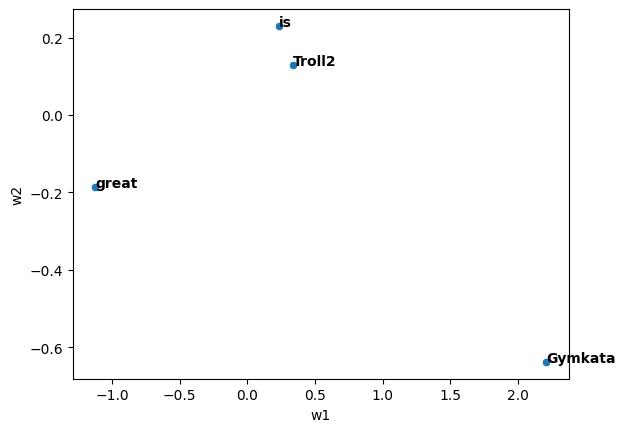

In [36]:
sns.scatterplot(data=df, x="w1", y="w2")

## add the token each dot represents to the graph
## NOTE: For Troll2 and and Gymkata, we're adding offsets to where to print the tokens because otherwise
## they will be so close to each other that they will overlap and be unreadable.
plt.text(df.w1[0], df.w2[0], df.token[0],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold') # Troll 2
plt.text(df.w1[1], df.w2[1], df.token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold') # is
plt.text(df.w1[2], df.w2[2], df.token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold') # great
plt.text(df.w1[3], df.w2[3], df.token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold') # Gymkata

plt.show()

In [37]:
trainer = L.Trainer(max_epochs=100)
trainer.fit(modelEmbed, train_dataloaders=dataloaderForEmbed)

/home/chason/anaconda3/envs/jupyter-server/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/chason/anaconda3/envs/jupyter-server/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/home/chason/anaconda3/envs/jupyter-server/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

In [38]:
print("After optimization, the parameters are...")
for name, param in modelEmbed.named_parameters():
    print(name, param.data)

After optimization, the parameters are...
embed.weight tensor([[ 1.7255,  2.6477],
        [ 0.9756, -2.5702],
        [-3.5512, -0.1337],
        [ 3.3123,  0.9554]])
hidden_to_output.weight tensor([[-6.0445e-01,  1.6247e-01],
        [ 1.6389e+00,  1.7619e+00],
        [ 1.6934e-03, -2.8041e+00],
        [-2.8600e+00,  7.4536e-02]])


In [39]:
weights = modelEmbed.embed.weight.detach().numpy()
w1 = [weights[0][0], weights[1][0], weights[2][0], weights[3][0]]
w2 = [weights[0][1], weights[1][1], weights[2][1], weights[3][1]]

In [40]:
data = {
    "w1": w1,
    "w2": w2,
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,1.725515,2.647720,Troll2,input1
1,0.975586,-2.570215,is,input2
2,-3.551202,-0.133739,great,input3
3,3.312251,0.955399,Gymkata,input4


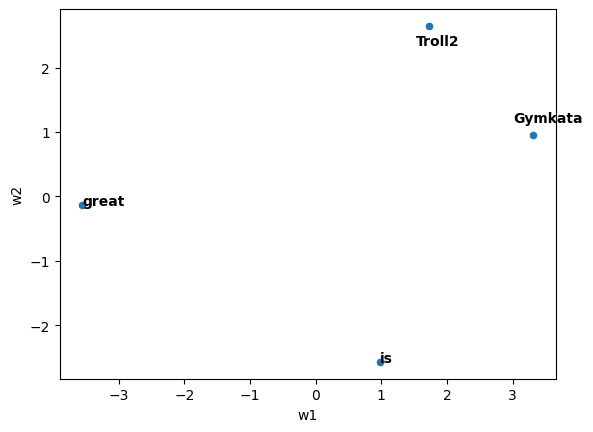

In [41]:
sns.scatterplot(data=df, x="w1", y="w2")

## add the token each dot represents to the graph
## NOTE: For Troll2 and and Gymkata, we're adding offsets to where to print the tokens because otherwise
## they will be so close to each other that they will overlap and be unreadable.
plt.text(df.w1[0]-0.2, df.w2[0]-0.3, df.token[0],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold') # Troll 2
plt.text(df.w1[1], df.w2[1], df.token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold') # is
plt.text(df.w1[2], df.w2[2], df.token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold') # great
plt.text(df.w1[3]-0.3, df.w2[3]+0.2, df.token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')# Gymkata

plt.show()

In [42]:
## Let's see what the model predicts
softmax = nn.Softmax(dim=0) ## dim=0 applies softmax to rows, dim=1 applies softmax to columns

print(torch.round(softmax(modelEmbed(torch.tensor([0])).detach()), decimals=2)) ## print the predictions for "Troll2"
print(torch.round(softmax(modelEmbed(torch.tensor([1])).detach()), decimals=2)) ## print the predictions for "is"
print(torch.round(softmax(modelEmbed(torch.tensor([2])).detach()), decimals=2)) ## print the predictions for "great"
print(torch.round(softmax(modelEmbed(torch.tensor([3])).detach()), decimals=2)) ## print the predictions for "Gymkata"

tensor([0., 1., 0., 0.])
tensor([0., 0., 1., 0.])
tensor([0., 0., 0., 1.])
tensor([0., 1., 0., 0.])
